In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


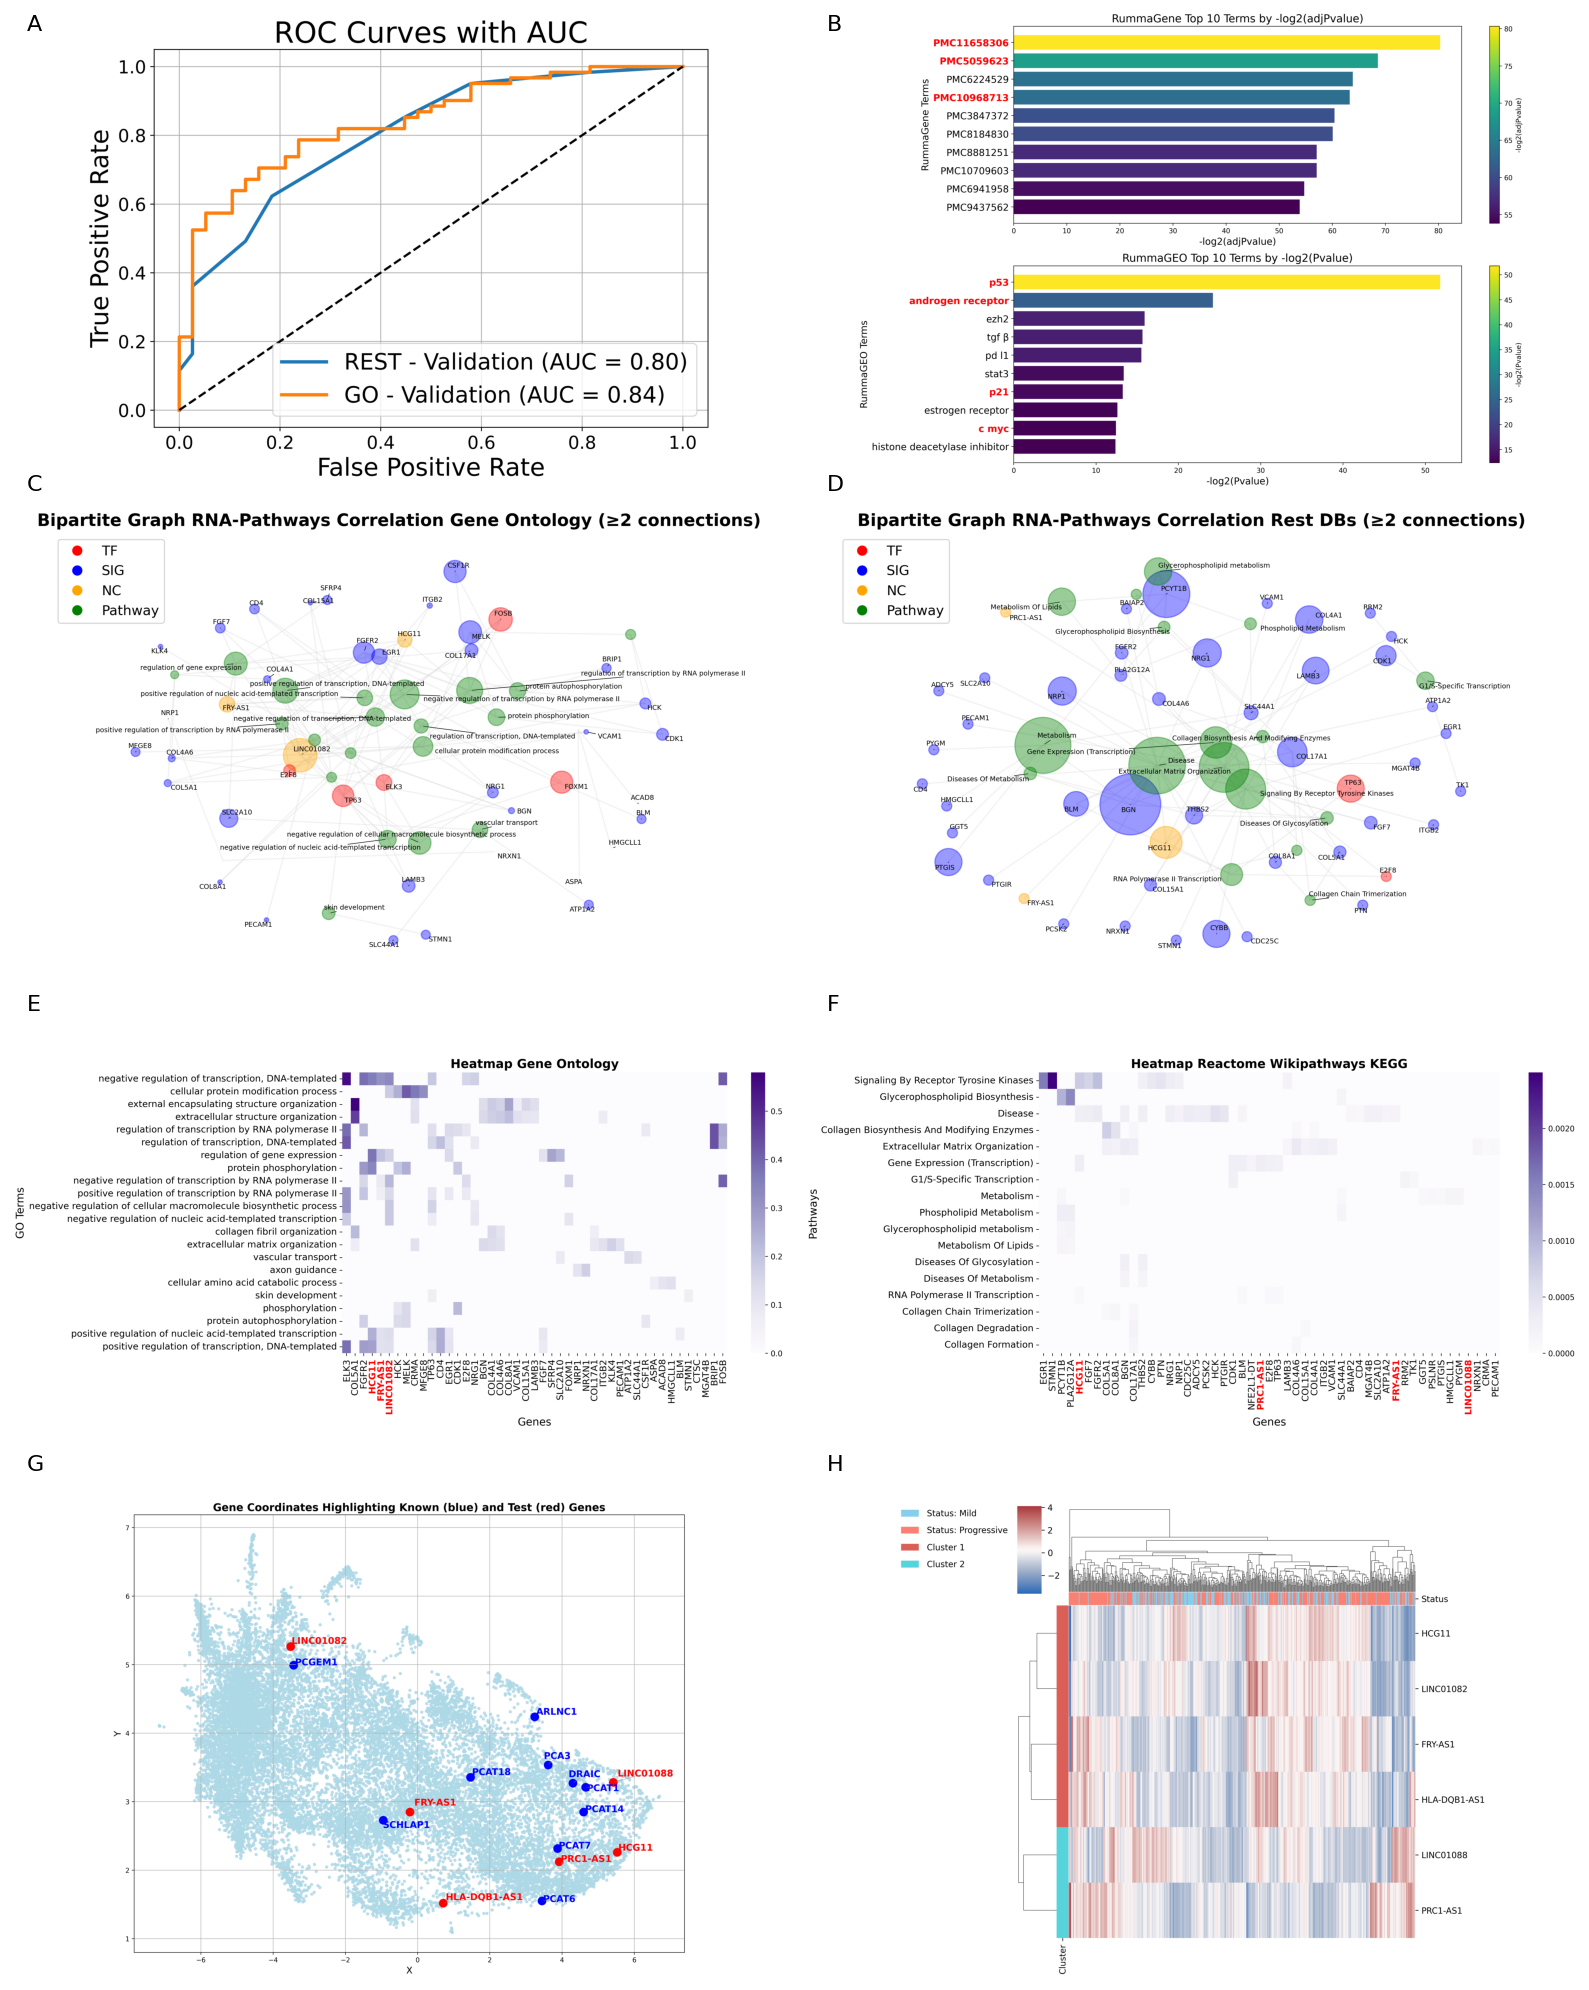

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import string

# -----------------------------
# List of images (row-major order for 4x2 layout)
# -----------------------------
image_files = [
    "AUC_ROC.png",
    "Rumma_top_panels_plot.png",
    "Bipartite_graph_Prostate_filtered_GO.png",
    "Bipartite_graph_Prostate_filtered_REST.png",
    "hierarchical_weights_heatmap_GO.png",
    "hierarchical_weights_heatmap_rest.png",
    "lncRNAs_umap.png",
    "TCGA_clustermap_onlyNC.png"
]

# Base path
base_path = "../../figures"

# Load images
images = [mpimg.imread(os.path.join(base_path, fname)) for fname in image_files]

# -----------------------------
# Create 4x2 multipanel figure
# -----------------------------
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')  # hide axes

plt.tight_layout()

# -----------------------------
# Add panel labels using fig.text for consistent alignment
# -----------------------------
panel_labels = list(string.ascii_uppercase)  # ['A', 'B', 'C', ...]

# Coordinates for 4x2 grid (normalized figure coordinates)
x_positions = [0.02, 0.52]  # left column, right column
y_positions = [0.99, 0.76, 0.50, 0.27]  # move E-H slightly lower

label_idx = 0
for row_y in y_positions:
    for col_x in x_positions:
        if label_idx < len(panel_labels):
            fig.text(
                col_x, row_y, panel_labels[label_idx],
                fontsize=16,
                fontweight='normal',
                va='top',
                ha='left',
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', pad=2, alpha=0.7)
            )
            label_idx += 1

# -----------------------------
# Save figure
# -----------------------------
plt.savefig("../../figures/multipanel_4x2_figure_MAIN.png", dpi=300, bbox_inches="tight")
plt.show()
